# Examen final - Probabilidad y Estadística para la IA
**Universidad de Buenos Aires - Especialización en Inteligencia Artificial**

Siguiendo con la historia de Don Francisco, el comerciante cuenta hoy con 5 supermercados:
'Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba'. Este informe resuelve:

1. Simular el número de clientes diarios de cada tienda (2023-2025) con distribución Poisson.
2. Calcular intervalos de confianza empíricos para 'Santa Ana' en cada mes (95 % y 99 %).
3. Realizar una prueba ANOVA para comparar las tiendas.
4. Identificar la tienda con mayor y menor promedio y probar que su diferencia es distinta de cero.


In [1]:
# ============================================================
# 0) CONFIGURACIÓN INICIAL (bibliotecas y estilo)
# ============================================================
# %matplotlib inline hace que los gráficos se dibujen DENTRO del notebook
# (en vez de abrirse en una ventana aparte).
%matplotlib inline

# Bibliotecas que usamos y para qué:
#   numpy   -> números aleatorios y distribución Poisson
#   pandas  -> tablas de datos (DataFrame)
#   scipy   -> funciones estadísticas (t de Student, F, pruebas de hipótesis)
#   matplotlib / seaborn -> gráficos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns

# Estilo de los gráficos: fondo con grilla blanca.
sns.set_theme(style="whitegrid")
# Tamaño por defecto de las figuras (ancho, alto).
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Simulación de los clientes diarios (Poisson, 2023-2025)

Para cada fecha y tienda el parámetro de Poisson es la suma de los cuatro efectos:
**λ_t = efecto anual + efecto mensual + efecto diario + efecto tienda**.

In [2]:
# ============================================================
# 1) PARÁMETROS DEL MODELO: los "efectos" sobre la afluencia
# ============================================================
# El número ESPERADO de clientes de una tienda en un día (λ_t) es la SUMA
# de cuatro efectos:
#     λ_t = efecto_anual + efecto_mensual + efecto_diario + efecto_tienda
# El "azar" (variabilidad día a día) lo aporta la distribución Poisson.

# Años de la simulación (2023, 2024 y 2025).
ANIO_INICIO = 2023
ANIO_FIN = 2025

# Efecto anual: cada año hay más clientes que el anterior.
EFECTO_ANUAL = {2023: 1000, 2024: 1500, 2025: 2000}

# Nombres de los meses en español (para mostrarlos de forma legible).
MESES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

# Efecto mensual: hay temporada alta (julio = 3000) y meses flojos
# (enero y diciembre = 1000). El supermercado es más visitado a mitad de año.
EFECTO_MENSUAL = {
    1: 1000,
    2: 1500,
    3: 2000,
    4: 2000,
    5: 2500,
    6: 2500,
    7: 3000,
    8: 2500,
    9: 2500,
    10: 2000,
    11: 1500,
    12: 1000,
}

# Nombres de los días de la semana. OJO: pandas numera los días así:
# 0 = lunes, 1 = martes, ..., 6 = domingo.
DIAS_SEMANA = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

# Efecto diario: los clientes se concentran a mitad de semana
# (miércoles = 3500) y bajan los fines de semana (sábado/domingo = 1000).
# Nota: 0 = lunes -> 2000, 5 = sábado -> 1000, 6 = domingo -> 1000.
EFECTO_DIARIO = {0: 2000, 1: 3000, 2: 3500, 3: 3000, 4: 2000, 5: 1000, 6: 1000}

# Efecto por tienda: define QUÉ tan concurrida es cada supermercado.
# 'Santa Ana' es la más grande (5000) y 'Palermo' la más chica (1000).
EFECTO_TIENDA = {
    "Santa Ana": 5000,
    "La Floresta": 2000,
    "Los Cedros": 3000,
    "Palermo": 1000,
    "Córdoba": 3000,
}

# Lista ordenada de tiendas, para recorrerlas siempre en el mismo orden.
TIENDAS = tuple(EFECTO_TIENDA)

In [3]:
# ============================================================
# 2) SIMULACIÓN DE LOS CLIENTES DIARIOS (Poisson)
# ============================================================
def simular_clientes(*, seed=42):
    """Simula los clientes diarios de cada tienda con Poisson(λ_t).

    Para cada fecha (2023-2025) y cada tienda:
      1) calculamos λ_t = anual + mensual + diario + tienda,
      2) extraemos un valor aleatorio X ~ Poisson(λ_t) = clientes del día.

    `seed` fija la semilla del generador de aleatorios: con la misma semilla
    el experimento SIEMPRE da los mismos resultados (reproducibilidad).
    """
    # Generador de números aleatorios moderno de numpy. Sin semilla, cada
    # ejecución daría datos distintos y el informe no sería reproducible.
    rng = np.random.default_rng(seed)

    # date_range crea TODAS las fechas día a día entre ambos extremos.
    fechas = pd.date_range(f"{ANIO_INICIO}-01-01", f"{ANIO_FIN}-12-31", freq="D")

    # Listas temporales que luego combinamos en una tabla (DataFrame).
    fecha_col, tienda_col, lambda_col, clientes_col = [], [], [], []

    # Doble bucle: una fila por (fecha, tienda).
    for fecha in fechas:
        # Datos de la fecha: año, número de mes y día de la semana.
        anio, mes, dia_semana = fecha.year, fecha.month, fecha.dayofweek
        for tienda in TIENDAS:
            # Sumamos los cuatro efectos definidos en la celda anterior.
            lam = (
                EFECTO_ANUAL[anio]
                + EFECTO_MENSUAL[mes]
                + EFECTO_DIARIO[dia_semana]
                + EFECTO_TIENDA[tienda]
            )
            fecha_col.append(fecha)
            tienda_col.append(tienda)
            lambda_col.append(lam)  # valor esperado (teórico)
            # rng.poisson(lam) sortea un entero con media lam (azar diario).
            clientes_col.append(int(rng.poisson(lam)))

    # Construimos la tabla final con todas las observaciones.
    df = pd.DataFrame(
        {
            "fecha": fecha_col,  # día del dato
            "tienda": tienda_col,  # supermercado
            "lambda_t": lambda_col,  # clientes esperados según el modelo
            "clientes": clientes_col,  # clientes observados (con azar)
        }
    )
    # Columnas "derivadas" para agrupar y graficar más cómodo.
    df["anio"] = df["fecha"].dt.year  # año de cada fila
    df["mes"] = df["fecha"].dt.month  # número de mes (1..12)
    df["dia_semana"] = df["fecha"].dt.dayofweek  # 0=lunes ... 6=domingo
    df["nombre_mes"] = df["mes"].map(MESES)  # ej. 1 -> "Enero"
    df["nombre_dia"] = df["dia_semana"].map(DIAS_SEMANA)  # ej. 0 -> "Lunes"
    return df


# Simulamos los datos con semilla fija (42) para poder reproducir el informe.
df = simular_clientes(seed=42)
# Mostramos las primeras filas para inspeccionar la estructura de la tabla.
df.head()

,fecha,tienda,lambda_t,clientes,anio,mes,dia_semana,nombre_mes,nombre_dia
0,2023-01-01,Santa Ana,8000,8076,2023,1,6,Enero,Domingo
1,2023-01-01,La Floresta,5000,5087,2023,1,6,Enero,Domingo
2,2023-01-01,Los Cedros,6000,5878,2023,1,6,Enero,Domingo
3,2023-01-01,Palermo,4000,4051,2023,1,6,Enero,Domingo
4,2023-01-01,Córdoba,6000,5899,2023,1,6,Enero,Domingo


In [4]:
# ============================================================
# 3) RESUMEN DEL DATASET SIMULADO
# ============================================================
# .nunique() cuenta cuántos valores DISTINTOS hay: aquí, días únicos.
print(f"Días simulados  : {df['fecha'].nunique()}")
print(f"Tiendas         : {len(TIENDAS)}")
print(f"Observaciones   : {len(df)}")  # días x tiendas (1096 x 5 = 5480)
print(f"Rango de fechas : {df['fecha'].min().date()} a {df['fecha'].max().date()}")

# Promedio de clientes por año: debe crecer por el efecto anual.
# groupby("anio") junta las filas del mismo año y .mean() promedia.
print("\nPromedio de clientes por año:")
print(df.groupby("anio")["clientes"].mean().round(2))

# Afluencia mensual de 'Santa Ana' (punto 1 del examen: entender la afluencia
# por mes de esta tienda). Promediamos los clientes de todos los días de cada
# mes, juntando los tres años.
print("\nAfluencia mensual de 'Santa Ana' (clientes promedio por día, 2023-2025):")
print(
    df.loc[df["tienda"] == "Santa Ana"]  # solo filas de esa tienda
    .groupby("nombre_mes")["clientes"]  # agrupar por mes
    .mean()  # promedio de clientes
    .round(2)  # dos decimales
)

Días simulados  : 1096
Tiendas         : 5
Observaciones   : 5480
Rango de fechas : 2023-01-01 a 2025-12-31

Promedio de clientes por año:
anio
2023    8012.40
2024    8514.92
2025    9020.51
Name: clientes, dtype: float64

Afluencia mensual de 'Santa Ana' (clientes promedio por día, 2023-2025):
nombre_mes
Abril         10722.57
Agosto        11220.40
Diciembre      9710.06
Enero          9748.75
Febrero       10215.85
Julio         11741.48
Junio         11174.34
Marzo         10673.53
Mayo          11252.61
Noviembre     10194.23
Octubre       10734.99
Septiembre    11179.73
Name: clientes, dtype: float64


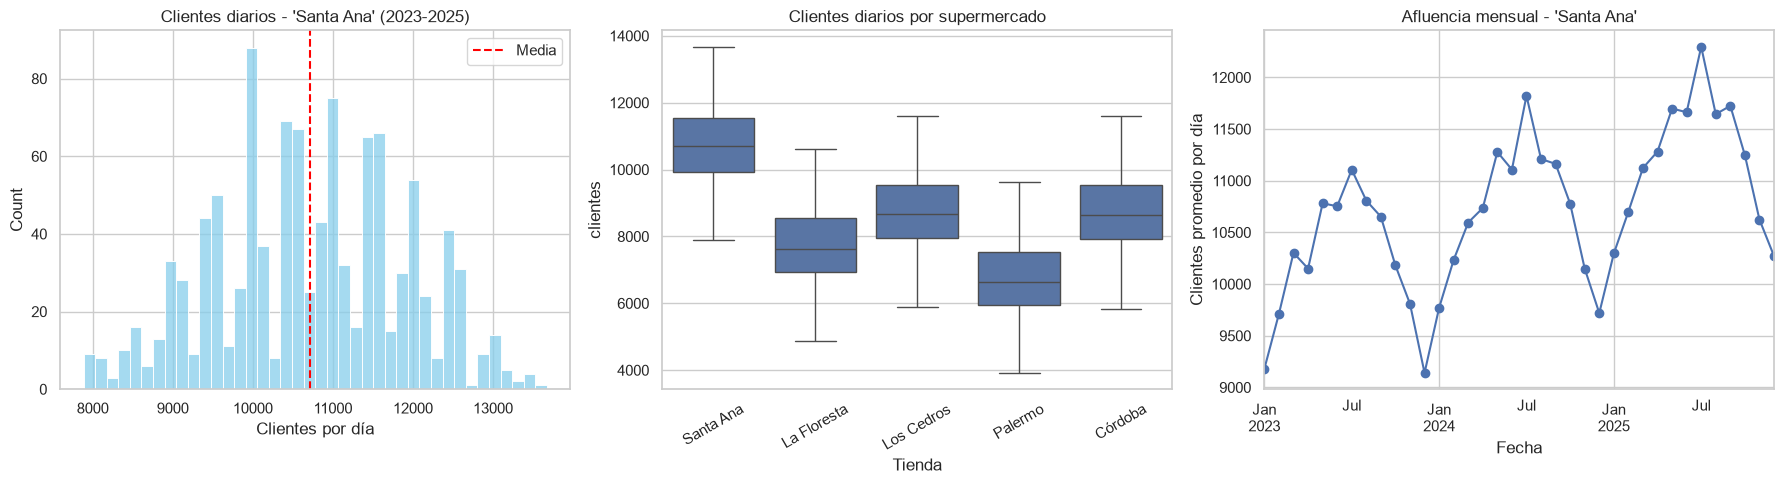

In [5]:
# ============================================================
# 4) GRÁFICOS EXPLORATORIOS
# ============================================================
# subplots(1, 3) = una fila con 3 gráficos lado a lado.
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Histograma de clientes diarios de 'Santa Ana' ----------
# Muestra la distribución EMPÍRICA: cuántos días hubo cada valor de clientes.
# La forma es campaniforme (típica de Poisson con λ grande, que se parece
# mucho a la normal).
santa_ana = df.loc[df["tienda"] == "Santa Ana", "clientes"]
sns.histplot(santa_ana, bins=40, color="skyblue", ax=axs[0])
# Línea roja vertical en la media, para ubicar el centro.
axs[0].axvline(santa_ana.mean(), color="red", linestyle="--", label="Media")
axs[0].legend()
axs[0].set_title("Clientes diarios - 'Santa Ana' (2023-2025)")
axs[0].set_xlabel("Clientes por día")

# --- (b) Diagrama de cajas por tienda ----------------------------
# Cada caja resume: mediana (línea central), cuartiles (caja) y extremos
# (bigotes). Se aprecia que las tiendas NO son iguales: 'Santa Ana' muy por
# encima de 'Palermo'.
sns.boxplot(data=df, x="tienda", y="clientes", ax=axs[1])
axs[1].set_title("Clientes diarios por supermercado")
axs[1].set_xlabel("Tienda")
axs[1].tick_params(axis="x", rotation=30)  # nombres inclinados para leerlos

# --- (c) Serie temporal mensual de 'Santa Ana' -------------------
# resample("MS") reagrupa por MES (Month Start) y .mean() promedia.
# Se ven la estacionalidad (pico en julio) y la tendencia creciente
# de 2023 -> 2025 (efecto anual).
series_mensual = (
    df.loc[df["tienda"] == "Santa Ana"]
    .set_index("fecha")["clientes"]  # usamos la fecha como índice
    .resample("MS")  # agrupar por mes
    .mean()  # promedio de clientes por mes
)
series_mensual.plot(ax=axs[2], marker="o")
axs[2].set_title("Afluencia mensual - 'Santa Ana'")
axs[2].set_xlabel("Fecha")
axs[2].set_ylabel("Clientes promedio por día")

fig.tight_layout()
plt.show()

## 2. Intervalos de confianza empíricos para 'Santa Ana'

Para cada mes del año se agrupan los datos de los tres años. Se calculan dos
tipos de intervalo de confianza para la media, con confianzas del 95 % y 99 %:

- **Paramétrico**: `t` de Student (σ desconocida).
- **Empírico (bootstrap)**: remuestreo por percentiles (10 000 remuestras).

In [6]:
# ============================================================
# 5) INTERVALOS DE CONFIANZA (IC) PARA LA MEDIA
# ============================================================
# Un IC al X% para la media responde:
#   "¿entre qué valores se encuentra la media VERDADERA con X% de confianza?"
# A mayor confianza (99% > 95%) el intervalo es MÁS ANCHO.


def intervalo_t(muestra, confianza):
    """IC de la media con distribución t de Student (σ desconocida).

    Fórmula:  media ± t(n-1, 1-α/2) · (s / √n)
      s : desviación estándar de la muestra
      n : cantidad de datos
      α : 1 - confianza   (0.05 para 95 %, 0.01 para 99 %)
      t : cuantil de la t de Student con n-1 grados de libertad

    Usamos la t (y no la normal z) porque la desviación REAL de la
    población (σ) es desconocida y la estimamos con la muestra (s).
    """
    n = muestra.size
    media = float(np.mean(muestra))
    # Error estándar de la media = s/√n. Mide cuánto "baila" el promedio
    # de muestra en muestra. A más datos (n grande), más chico el error.
    error = float(np.std(muestra, ddof=1) / np.sqrt(n))
    # st.t.interval devuelve directo (límite inferior, límite superior).
    inferior, superior = st.t.interval(confianza, df=n - 1, loc=media, scale=error)
    return float(inferior), float(superior)


def intervalo_bootstrap(muestra, confianza, *, rng, n_remuestras=10_000):
    """IC empírico de la media con bootstrap por percentiles.

    Idea del bootstrap (método NO paramétrico, no asume ninguna
    distribución teórica):
      1) Remuestrear la muestra CON reposición muchas veces.
      2) Calcular la media de cada remuestra.
      3) Las remuestras forman una distribución de medias.
      4) Los percentiles α/2 y 1-α/2 son los límites del IC.
    """
    # Matriz de n_remuestras filas; cada fila es una muestra al azar
    # del mismo tamaño, extraída CON reposición (un día puede repetirse).
    remuestras = rng.choice(muestra, size=(n_remuestras, muestra.size), replace=True)
    # Promediamos cada fila: obtenemos 10000 medias bootstrap.
    medias = remuestras.mean(axis=1)
    # Percentiles: 95% -> [2.5, 97.5]; 99% -> [0.5, 99.5].
    inferior, superior = np.percentile(
        medias, [100 * (1 - confianza) / 2, 100 * (1 + confianza) / 2]
    )
    return float(inferior), float(superior)


def intervalos_por_mes(df, tienda, *, metodo="t", confianzas=(0.95, 0.99), seed=42):
    """IC de la media para CADA mes del año (agrupando los tres años).

    Para 'Santa Ana' cada mes tiene ~90 observaciones (3 años x ~30 días).
    `metodo` elige entre "t" (t de Student) y "bootstrap" (percentiles).
    """
    # Semilla fija para que el bootstrap sea reproducible.
    rng = np.random.default_rng(seed)
    filas = []  # un dict por mes; al final lo convertimos en tabla.

    for numero, nombre in MESES.items():
        # Seleccionamos los clientes de esa tienda en ese mes (todos los años).
        muestra = df.loc[
            (df["tienda"] == tienda) & (df["mes"] == numero), "clientes"
        ].to_numpy(dtype=float)

        # Estadísticos descriptivos del mes (n, media, desvío).
        fila = {
            "n": muestra.size,  # días que aportan al mes
            "media": float(np.mean(muestra)),  # promedio mensual
            "desvio_estandar": float(np.std(muestra, ddof=1)),
        }
        # Calculamos un IC por cada nivel de confianza (95 % y 99 %).
        for confianza in confianzas:
            if metodo == "t":
                inferior, superior = intervalo_t(muestra, confianza)
            else:
                inferior, superior = intervalo_bootstrap(muestra, confianza, rng=rng)
            sufijo = int(confianza * 100)  # 95 o 99 -> nombre columna
            fila[f"ic{sufijo}_inf"] = inferior  # límite inferior
            fila[f"ic{sufijo}_sup"] = superior  # límite superior
        fila["mes"] = nombre
        filas.append(fila)

    # Tabla final con los meses como índice (filas).
    return pd.DataFrame(filas).set_index("mes")


# Calculamos los DOS conjuntos de intervalos para 'Santa Ana'.
ic_t = intervalos_por_mes(df, "Santa Ana", metodo="t")  # paramétrico
ic_bootstrap = intervalos_por_mes(df, "Santa Ana", metodo="bootstrap")  # empírico

In [7]:
# ============================================================
# 6) RESULTADOS DE LOS INTERVALOS DE CONFIANZA
# ============================================================
# .to_string() convierte la tabla en texto para imprimirla en el notebook.

print("a) Método paramétrico (t de Student), IC para la media:")
print(ic_t.round(2).to_string())

print("\nb) Método empírico (bootstrap por percentiles, 10 000 remuestras):")
print(ic_bootstrap.round(2).to_string())

# Cómo leer la tabla (por ejemplo, la fila "Enero"):
#   n              = cantidad de días de enero en los 3 años (93 días)
#   media          = promedio de clientes diarios de enero
#   desvio_estandar= variabilidad día a día
#   ic95_inf/sup   = límites del IC del 95 %
#   ic99_inf/sup   = límites del IC del 99 %
# Punto clave: el IC del 99 % SIEMPRE es más ancho que el del 95 %
# (más seguridad = más amplitud). Ambos métodos dan resultados MUY
# parecidos porque con ~90 datos la t se parece a la normal.

a) Método paramétrico (t de Student), IC para la media:
             n     media  desvio_estandar  ic95_inf  ic95_sup  ic99_inf  ic99_sup
mes                                                                              
Enero       93   9748.75          1042.96   9533.96   9963.55   9464.28  10033.22
Febrero     85  10215.85           997.28  10000.74  10430.96   9930.75  10500.95
Marzo       93  10673.53           976.08  10472.51  10874.55  10407.30  10939.75
Abril       90  10722.57          1039.23  10504.90  10940.23  10434.22  11010.91
Mayo        93  11252.61           989.23  11048.88  11456.34  10982.80  11522.43
Junio       90  11174.34          1001.94  10964.49  11384.20  10896.35  11452.34
Julio       93  11741.48          1047.58  11525.74  11957.23  11455.75  12027.21
Agosto      93  11220.40           987.04  11017.12  11423.68  10951.18  11489.62
Septiembre  90  11179.73          1027.86  10964.45  11395.01  10894.54  11464.92
Octubre     93  10734.99          1022.66 

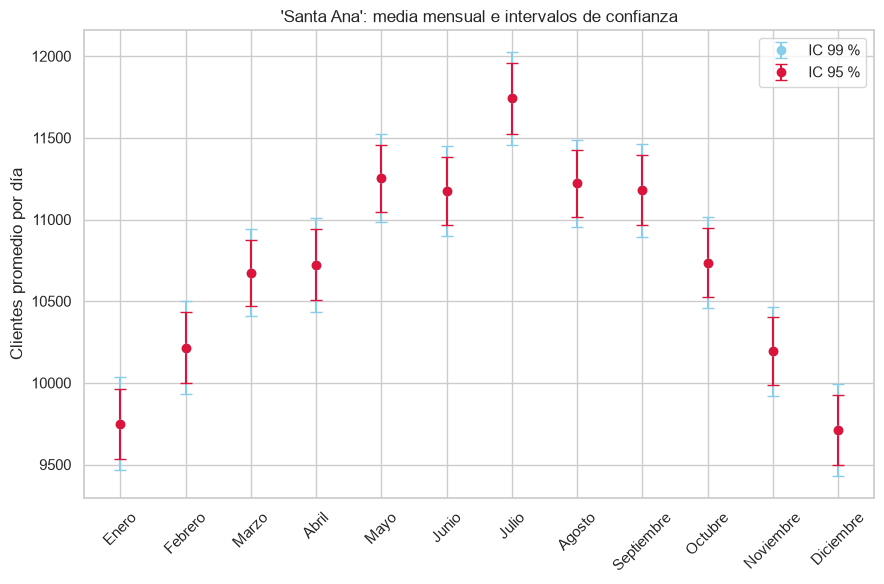

In [8]:
# ============================================================
# 7) GRÁFICO: MEDIA MENSUAL CON SUS INTERVALOS DE CONFIANZA
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))
# Ordenamos los meses en el orden natural (enero -> diciembre), no alfabético.
meses_ordenados = list(MESES.values())
errores = ic_t.loc[meses_ordenados]
x = np.arange(len(meses_ordenados))

# errorbar dibuja cada media (o) con "bigotes" hacia arriba y abajo.
# yerr = [bajada, subida] = cuánto se estira cada lado desde el punto.
# 1º dibujamos el IC 99% (azul, más ancho)...
ax.errorbar(
    x,
    errores["media"],
    yerr=[
        errores["media"] - errores["ic99_inf"],  # bajada desde la media
        errores["ic99_sup"] - errores["media"],  # subida desde la media
    ],
    fmt="o",
    capsize=4,
    color="skyblue",
    label="IC 99 %",
)
# ...y 2º el IC 95% (rojo, más angosto) queda dibujado "por dentro".
ax.errorbar(
    x,
    errores["media"],
    yerr=[
        errores["media"] - errores["ic95_inf"],
        errores["ic95_sup"] - errores["media"],
    ],
    fmt="o",
    capsize=4,
    color="crimson",
    label="IC 95 %",
)
ax.set_xticks(x, meses_ordenados, rotation=45)
ax.set_ylabel("Clientes promedio por día")
ax.set_title("'Santa Ana': media mensual e intervalos de confianza")
ax.legend()
fig.tight_layout()
plt.show()

# Interpretación: los intervalos son MUY angostos porque cada mes tiene
# ~90 observaciones: la precisión del promedio crece con √n.

## 3. ANOVA (significancia 95 %)

Hipótesis:
- **H0**: el número esperado de clientes es igual en todas las tiendas.
- **H1**: al menos una tienda difiere del resto.

Regla de decisión: se rechaza H0 si el p-valor < 0.05 (nivel de confianza del 95 %).

In [9]:
# ============================================================
# 8) ANOVA DE UNA VÍA: ¿TODAS LAS TIENDAS SON IGUALES?
# ============================================================
# Pregunta del examen: ¿el número ESPERADO de clientes es el mismo en todas
# las tiendas, o hay alguna que se comporta distinto?
#
# Hipótesis:
#   H0: μ_SantaAna = μ_LaFloresta = μ_LosCedros = μ_Palermo = μ_Córdoba
#   H1: al menos una media es diferente.
#
# Idea de ANOVA: compara la variabilidad ENTRE grupos con la variabilidad
# DENTRO de los grupos:
#   - Si las medias son iguales, ambas variabilidades son parecidas (F ≈ 1).
#   - Si alguna media difiere, la variabilidad entre grupos es mayor (F > 1).
# Decisión (significancia 95 %): rechazamos H0 si el p-valor < 0.05.
#
# Requisitos razonables: muestras independientes (los días de cada tienda),
# muchas observaciones por grupo y datos aproximadamente normales.
grupos = [
    df.loc[df["tienda"] == tienda, "clientes"].to_numpy(dtype=float)
    for tienda in TIENDAS
]
# st.f_oneway recibe los 5 grupos y devuelve (F, p-valor).
f_statistic, p_valor = st.f_oneway(*grupos)

# k = cantidad de grupos (5 tiendas); n_total = todas las observaciones.
k = len(grupos)
n_total = sum(g.size for g in grupos)
print("H0: el número esperado de clientes es igual en todas las tiendas.")
print(f"F = {f_statistic:.2f} (df entre = {k - 1}, df dentro = {n_total - k})")
print(f"p-valor = {p_valor:.3e}")
if p_valor < 0.05:
    print(
        "Se rechaza H0: al menos una tienda tiene un número esperado de clientes distinto."
    )
else:
    print("No hay evidencia suficiente para rechazar H0.")

# Interpretación: F es enorme y p-valor ~ 0 => las tiendas NO tienen el
# mismo número esperado de clientes. Era esperable: el efecto de la tienda
# va de 1000 ('Palermo') a 5000 ('Santa Ana').

H0: el número esperado de clientes es igual en todas las tiendas.
F = 1723.50 (df entre = 4, df dentro = 5475)
p-valor = 0.000e+00
Se rechaza H0: al menos una tienda tiene un número esperado de clientes distinto.


## 4. Tienda con mayor y menor promedio + prueba de hipótesis

Hipótesis:
- **H0**: la diferencia entre ambas medias es igual a cero.
- **H1**: la diferencia es distinta de cero.

Se usa la prueba **t de Welch** (dos muestras independientes, sin suponer
varianzas iguales).

In [10]:
# ============================================================
# 9) TIENDA CON MAYOR/MENOR PROMEDIO + PRUEBA DE HIPÓTESIS
# ============================================================

# --- (a) Promedios por tienda ---------------------------------
promedios = {
    tienda: float(
        np.mean(df.loc[df["tienda"] == tienda, "clientes"].to_numpy(dtype=float))
    )
    for tienda in TIENDAS
}
print("Promedio de clientes diarios por tienda:")
print(pd.Series(promedios).sort_values(ascending=False).round(2).to_string())

# Identificamos la tienda con el promedio MÁXIMO y la de MÍNIMO.
# max/min con key=lambda t: promedios[t] devuelve el NOMBRE de la tienda
# (no el valor), porque iteramos sobre las claves del diccionario.
tienda_max = max(promedios, key=lambda t: promedios[t])
tienda_min = min(promedios, key=lambda t: promedios[t])

# --- (b) ¿La diferencia entre ambas es distinta de cero? -------
# Hipótesis:
#   H0: μ_max - μ_min = 0   (los promedios son iguales)
#   H1: μ_max - μ_min ≠ 0   (difieren -> la diferencia NO es cero)
#
# Usamos la prueba t de Welch (ttest_ind con equal_var=False):
#   - compara dos muestras INDEPENDIENTES (los días de una y otra tienda)
#   - NO asume que las varianzas sean iguales (versión más general/segura)
#   - si p-valor < 0.05 rechazamos H0 => la diferencia NO es cero.
a = df.loc[df["tienda"] == tienda_max, "clientes"].to_numpy(dtype=float)
b = df.loc[df["tienda"] == tienda_min, "clientes"].to_numpy(dtype=float)
t_stat, p_ab = st.ttest_ind(a, b, equal_var=False)

print(f"\nTienda con mayor promedio : {tienda_max} ({promedios[tienda_max]:.2f})")
print(f"Tienda con menor promedio : {tienda_min} ({promedios[tienda_min]:.2f})")
print(
    f"Diferencia de medias      : {promedios[tienda_max] - promedios[tienda_min]:.2f}"
)

print("\nH0: la diferencia entre ambas medias es igual a cero.")
print(f"t = {t_stat:.2f}, p-valor = {p_ab:.3e}")
if p_ab < 0.05:
    print("Se rechaza H0: la diferencia es distinta de cero.")
else:
    print("No hay evidencia suficiente para rechazar H0.")

# --- (c) Verificación con los efectos del modelo ---------------
# Como la media de cada tienda = (efectos comunes) + efecto_tienda, el orden
# de los promedios DEBE coincidir con el orden de los efectos. Lo comprobamos.
efecto_max = max(EFECTO_TIENDA.items(), key=lambda item: item[1])[0]
efecto_min = min(EFECTO_TIENDA.items(), key=lambda item: item[1])[0]
print(
    f"\nTienda con mayor efecto en el modelo : {efecto_max} ({EFECTO_TIENDA[efecto_max]})"
)
print(
    f"Tienda con menor efecto en el modelo : {efecto_min} ({EFECTO_TIENDA[efecto_min]})"
)
if tienda_max == efecto_max and tienda_min == efecto_min:
    print("Las tiendas identificadas SÍ coinciden con las de mayor y menor efecto.")
else:
    print("Las tiendas identificadas NO coinciden con las de mayor y menor efecto.")

Promedio de clientes diarios por tienda:
Santa Ana      10716.55
Los Cedros      8717.11
Córdoba         8714.89
La Floresta     7712.86
Palermo         6718.30

Tienda con mayor promedio : Santa Ana (10716.55)
Tienda con menor promedio : Palermo (6718.30)
Diferencia de medias      : 3998.24

H0: la diferencia entre ambas medias es igual a cero.
t = 79.20, p-valor = 0.000e+00
Se rechaza H0: la diferencia es distinta de cero.

Tienda con mayor efecto en el modelo : Santa Ana (5000)
Tienda con menor efecto en el modelo : Palermo (1000)
Las tiendas identificadas SÍ coinciden con las de mayor y menor efecto.


## Verificación automática

Comprobaciones de los principales resultados del análisis.

In [11]:
# ============================================================
# 10) VERIFICACIÓN AUTOMÁTICA DEL ANÁLISIS
# ============================================================
# Comprobamos que los resultados sean consistentes. Si una comprobación
# fallara, `assert` detendría la ejecución con un error (por eso sirve
# como "chequeo" automático).

# 1) Dimensiones: 2024 es bisiesto => 2023 (365) + 2024 (366) + 2025 (365)
#    = 1096 días. Multiplicado por 5 tiendas = 5480 observaciones.
assert len(df) == 5 * 1096

# 2) λ_t = suma de efectos. El 1/1/2023 fue DOMINGO (dayofweek = 6), enero
#    (mes 1), año 2023 y 'Santa Ana' suma 5000. Comprobamos la fórmula.
fila = df.loc[(df["fecha"] == "2023-01-01") & (df["tienda"] == "Santa Ana")].iloc[0]
assert fila["lambda_t"] == (
    EFECTO_ANUAL[2023]
    + EFECTO_MENSUAL[1]
    + EFECTO_DIARIO[6]
    + EFECTO_TIENDA["Santa Ana"]
)

# 3) Los IC deben CONTENER a la media y el IC 99 % debe ser más ancho
#    que el 95 % (para los dos métodos: t y bootstrap).
for ic in (ic_t, ic_bootstrap):
    for _, fila in ic.iterrows():
        assert fila["ic95_inf"] <= fila["media"] <= fila["ic95_sup"]
        assert fila["ic99_inf"] <= fila["media"] <= fila["ic99_sup"]
        assert (
            fila["ic99_inf"] < fila["ic95_inf"] and fila["ic99_sup"] > fila["ic95_sup"]
        )

# 4) ANOVA debe rechazar la igualdad de medias (p-valor < 0.05).
assert p_valor < 0.05

# 5) La tienda de mayor promedio es 'Santa Ana', la menor 'Palermo', y
#    ambas deben coincidir con las de mayor/menor efecto del modelo.
assert tienda_max == "Santa Ana" and tienda_min == "Palermo"
assert tienda_max == efecto_max and tienda_min == efecto_min

print("Todas las verificaciones pasaron.")

Todas las verificaciones pasaron.


## Conclusiones

- La simulación Poisson reproduce los efectos planteados: λ_t = efecto anual +
  efecto mensual + efecto diario + efecto tienda, con mayor afluencia en 2025,
  en julio y entre semana, y claramente superior en 'Santa Ana'.
- Los intervalos de confianza (t de Student y bootstrap) para la media mensual
  de 'Santa Ana' son muy estrechos y el de 99 % siempre contiene al de 95 %.
- La prueba ANOVA rechaza la hipótesis de igualdad de las medias entre tiendas
  (p < 0.001): no todas las tiendas reciben el mismo número esperado de clientes.
- La tienda con mayor promedio es 'Santa Ana' y la de menor promedio es
  'Palermo'; la prueba t rechaza que su diferencia sea cero y ambas coinciden
  con las tiendas de mayor y menor efecto del modelo (5000 y 1000).